# Vessel Data Quality Assessment: Statistical and Machine Learning Methods

This notebook presents a structured exploration of vessel sensor data as part of an ongoing research project on data quality improvement and anomaly detection in maritime systems.

The primary goal is to:
- Assess the quality and consistency of onboard sensor data,
- Identify correlations between key parameters (e.g., engine load, fuel flow, and vessel speed),
- Detect potential anomalies such as frozen, drifting, or out-of-range sensors.

The analysis combines **statistical techniques** (z-scores, interquartile ranges, correlation analysis) and **machine learning methods** (unsupervised anomaly detection models like Isolation Forest and Autoencoders).  

While the dataset provided represents only a small subset of operational data, it serves as a **proof of concept** for scalable methods applicable across multiple vessels and sensor systems.

---

**Notebook Objectives**
1. Explore and understand the dataset structure and variables.  
2. Evaluate overall data quality and detect missing or invalid readings.  
3. Analyze relationships and correlations between critical sensors.  
4. Apply statistical and ML-based anomaly detection techniques.  
5. Visualize and summarize findings to support data-driven insights.


## Installs, and Module Imports

For Installation, start a virtual env, activate it then install requirements.txt

Then import the modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import os
import warnings
from datetime import datetime
import glob
import json
from datetime import datetime, timedelta
import io
import datashader as ds
import datashader.transfer_functions as tf
from datashader.mpl_ext import dsshow
import colorcet
import hvplot.pandas
import holoviews as hv
from holoviews.operation.datashader import datashade, dynspread
hv.extension('bokeh')

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


## Data Imports

    Read one single Metadata file to see what type of fields are inlcuded

In [2]:
meta_path = "data/LNGMEGIA.CT056.01_Meas1_PRIM.meta"
with open(meta_path) as f:
    meta = json.load(f)

print(meta)

{'ExportMetaData': {'ExportDate': '2025-10-06T08:09:02.411285+01:00', 'ExportVersion': '1.1.3', 'ExportType': 2, 'TimestampPrecisionType': 1, 'ExportFrom': '2024-01-01T00:00:00Z', 'ExportTo': '2025-10-05T23:59:59.9999999Z', 'IncludeBadValues': True, 'TotalEvents': 132627, 'TotalGoodValues': 132526, 'TotalBadValues': 101, 'LowestFrequency': 0.0, 'HighestFrequency': 0.0926388888888889, 'AverageFrequency': 0.002383594289164973, 'FirstRecordedTimestamp': '2024-08-14T06:48:45.5350036Z', 'LastRecordedTimestamp': '2025-10-06T07:05:59.1210021Z'}, 'PointMetaData': {'ExportedFromServer': 'n08251-web1-001', 'PiPointName': 'LNGMEGIA.CT056.01/Meas1/PRIM', 'PointSource': 'ARANTHERA', 'PointType': 'Float32', 'DigitalSet': '', 'ExceptionDeviation': 0.0, 'ExceptionMaximum': 0, 'ExceptionMinimum': 0, 'ExceptionPercentage': 0.0, 'Descriptor': 'CGO TK4 AVERAGE LIQUID TEMP', 'Span': 100.0, 'Zero': 0.0, 'EngineeringUnits': '', 'Compressing': 1, 'Step': 0, 'CompressionDeviation': 0.0, 'CompressionMaximum': 0

    Iterate through all sensor folders, load metadata and data, attach metadata to each reading, and save all sensor's data in one csv file.

In [ ]:
base_dir = "data"
all_data = []

for folder in os.listdir(base_dir):
    if folder.endswith("_PRIM"):
        sensor_id = folder
        meta_path = os.path.join(base_dir, folder + ".meta")
        prim_dir = os.path.join(base_dir, folder)

        # --- Load .meta file ---
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)

        export_meta = meta.get("ExportMetaData", {})
        point_meta = meta.get("PointMetaData", {})

        # --- Iterate through all .txt files ---
        for txt_file in os.listdir(prim_dir):
            if not txt_file.endswith(".txt"):
                continue

            file_path = os.path.join(prim_dir, txt_file)

            # Read data, skip header lines starting with ';'
            with open(file_path, 'r') as f:
                lines = f.readlines()
            data_lines = [line for line in lines if not line.startswith(';')]

            # Parse data into DataFrame
            df = pd.read_csv(
                io.StringIO(''.join(data_lines)),
                names=["Timestamp", "Value", "ValueStatus"],
                parse_dates=["Timestamp"]
            )

            # Attach all ExportMetaData fields
            for k, v in export_meta.items():
                df[k] = v
            # Attach all PointMetaData fields
            for k, v in point_meta.items():
                df[k] = v
            # Also keep sensor_id for traceability
            df["sensor_id"] = sensor_id

            all_data.append(df)

# Combine everything
combined_df = pd.concat(all_data, ignore_index=True)
combined_df.sort_values("Timestamp", inplace=True)
combined_df.reset_index(drop=True, inplace=True)

print(combined_df.head())

# Save merged dataframe
os.makedirs("merged", exist_ok=True)
combined_df.to_csv("merged/merged_sensor_data.csv", index=False)

    The size of the merged dataframe is over 13GB, so we will be working on each sensor seperatly.

### Sensor Data Merge & Parquet Export
Iterate through all sensor folders, load metadata and data, attach metadata to each reading, and save each sensor's data as a Parquet file for efficient storage and analysis, and as CSV for better auditing/traceability. 

In [ ]:
base_dir = "data"
output_dir = "merged_parquet"
os.makedirs(output_dir, exist_ok=True)

for folder in os.listdir(base_dir):
    if folder.endswith("_PRIM"):
        sensor_id = folder
        meta_path = os.path.join(base_dir, folder + ".meta")
        prim_dir = os.path.join(base_dir, folder)

        # --- Load .meta file ---
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)

        export_meta = meta.get("ExportMetaData", {})
        point_meta = meta.get("PointMetaData", {})

        # --- Iterate through all .txt files ---
        for txt_file in os.listdir(prim_dir):
            if not txt_file.endswith(".txt"):
                continue

            file_path = os.path.join(prim_dir, txt_file)

            # Read data, skip header lines starting with ';'
            with open(file_path, 'r') as f:
                lines = f.readlines()
            # Only keep lines that do NOT start with ';'
            data_lines = [line for line in lines if not line.lstrip().startswith(';')]

            # Parse data into DataFrame
            df = pd.read_csv(
                io.StringIO(''.join(data_lines)),
                names=["Timestamp", "Value", "ValueStatus"]
            )
            # Robust timestamp conversion
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            
            # Attach all ExportMetaData fields
            for k, v in export_meta.items():
                df[k] = v
            # Attach all PointMetaData fields
            for k, v in point_meta.items():
                df[k] = v
            # Also keep sensor_id for traceability
            df["sensor_id"] = sensor_id

            # Save each sensor's data as Parquet
            parquet_path = os.path.join(output_dir, f"{sensor_id}_{txt_file.replace('.txt', '')}.parquet")
            df.to_parquet(parquet_path, index=False)

In [ ]:
base_dir = "data"
output_dir = "merged_csv"
os.makedirs(output_dir, exist_ok=True)

for folder in os.listdir(base_dir):
    if folder.endswith("_PRIM"):
        sensor_id = folder
        meta_path = os.path.join(base_dir, folder + ".meta")
        prim_dir = os.path.join(base_dir, folder)

        # --- Load .meta file ---
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)

        export_meta = meta.get("ExportMetaData", {})
        point_meta = meta.get("PointMetaData", {})

        # --- Iterate through all .txt files ---
        for txt_file in os.listdir(prim_dir):
            if not txt_file.endswith(".txt"):
                continue

            file_path = os.path.join(prim_dir, txt_file)

            # Read data, skip header lines starting with ';'
            with open(file_path, 'r') as f:
                lines = f.readlines()
            data_lines = [line for line in lines if not line.startswith(';')]

            # Parse data into DataFrame
            df = pd.read_csv(
                io.StringIO(''.join(data_lines)),
                names=["Timestamp", "Value", "ValueStatus"],
                parse_dates=["Timestamp"]
            )

            # Attach all ExportMetaData fields
            for k, v in export_meta.items():
                df[k] = v
            # Attach all PointMetaData fields
            for k, v in point_meta.items():
                df[k] = v
            # Also keep sensor_id for traceability
            df["sensor_id"] = sensor_id

            # Save each sensor's data as CSV
            csv_path = os.path.join(output_dir, f"{sensor_id}_{txt_file.replace('.txt', '')}.csv")
            df.to_csv(csv_path, index=False)

    With more issues when cleaning and preprocessing the data saving them into parquet wasn't very helpful so csv is used instead. And one global function is used to iterate through all folders, find their meta data, join all txt files within the folder then merge the meta data. this process is repeated for all sensors, so each has its own csv file. 

In [ ]:
def merge_sensor_with_meta(data_dir="data", output_dir="merged_csv"):
    import os
    import pandas as pd
    import json
    import io

    os.makedirs(output_dir, exist_ok=True)

    for folder in os.listdir(data_dir):
        if folder.endswith("_PRIM"):
            sensor_id = folder
            meta_path = os.path.join(data_dir, folder + ".meta")
            prim_dir = os.path.join(data_dir, folder)

            # Load .meta file
            with open(meta_path, 'r', encoding='utf-8') as f:
                meta = json.load(f)
            export_meta = meta.get("ExportMetaData", {})
            point_meta = meta.get("PointMetaData", {})

            all_data = []
            # Iterate through all .txt files and collect data
            for txt_file in os.listdir(prim_dir):
                if not txt_file.endswith(".txt"):
                    continue
                file_path = os.path.join(prim_dir, txt_file)
                # Read data, skip header lines starting with ';'
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                data_lines = [line for line in lines if not line.lstrip().startswith(';')]
                # Parse data into DataFrame
                df = pd.read_csv(
                    io.StringIO(''.join(data_lines)),
                    names=["Timestamp", "Value", "ValueStatus"]
                )
                # Attach all ExportMetaData fields
                for k, v in export_meta.items():
                    df[k] = v
                # Attach all PointMetaData fields
                for k, v in point_meta.items():
                    df[k] = v
                # Also keep sensor_id for traceability
                df["sensor_id"] = sensor_id
                all_data.append(df)

            # Merge all txt files for this sensor into one DataFrame
            if all_data:
                combined_df = pd.concat(all_data, ignore_index=True)
                combined_df.sort_values("Timestamp", inplace=True)
                combined_df.reset_index(drop=True, inplace=True)
                out_path = os.path.join(output_dir, f"{sensor_id}.csv")
                combined_df.to_csv(out_path, index=False)

In [ ]:
merge_sensor_with_meta(data_dir="data", output_dir="merged_csv")

## Data Overview

### Dataset Structure Analysis from Parquet Files
We'll analyze the sensor data stored in individual Parquet files to:
1. Get overall dataset properties
2. Understand sensor distributions
3. Examine data quality metrics
4. Identify patterns and anomalies

    Before doing bulk cleaning, I would like to explore one single sensor's file, see what are potential issues. then once a pattern is recognized, a global function will be implemented and the cleaning process will work on all sensor files.

In [3]:
# Load merged data
import pandas as pd
df = pd.read_csv(
    "merged/merged_sensor_data.csv",
    parse_dates=['Timestamp', 'ExportDate', 'FirstRecordedTimestamp', 'LastRecordedTimestamp']
)

In [4]:
# Data overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3808515 entries, 0 to 3808514
Data columns (total 39 columns):
 #   Column                  Dtype                    
---  ------                  -----                    
 0   Timestamp               object                   
 1   Value                   object                   
 2   ValueStatus             float64                  
 3   ExportDate              datetime64[ns, UTC+01:00]
 4   ExportVersion           object                   
 5   ExportType              int64                    
 6   TimestampPrecisionType  int64                    
 7   ExportFrom              object                   
 8   ExportTo                object                   
 9   IncludeBadValues        bool                     
 10  TotalEvents             int64                    
 11  TotalGoodValues         int64                    
 12  TotalBadValues          int64                    
 13  LowestFrequency         float64                  
 14  Hi

In [5]:
print(df.shape)

(3808515, 39)


In [6]:
df.describe(include='all')

,Timestamp,Value,ValueStatus,ExportDate,ExportVersion,ExportType,TimestampPrecisionType,ExportFrom,ExportTo,IncludeBadValues,...,Zero,EngineeringUnits,Compressing,Step,CompressionDeviation,CompressionMaximum,CompressionMinimum,CompressionPercentage,SanitizedFilename,sensor_id
count,3808515,3808515.000,3.808201e+06,3808515,3808515,3808515.0,3808515.0,3808515,3808515,3808515,...,3808515.0,0.0,3808515.0,3808515.0,3808515.0,3808515.0,3808515.0,3808515.0,3808515,3808515
unique,3808196,909645.000,NaN,NaN,1,NaN,NaN,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,; LNGMEGIA.CT_TOTALVOL/Meas1/PRIM,1929.158,NaN,NaN,1.1.3,NaN,NaN,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
freq,314,3931.000,NaN,NaN,3808515,NaN,NaN,3808515,3808515,3808515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3808515,3808515
mean,NaN,NaN,9.999215e-01,2025-10-06 08:09:02.411279616+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
min,NaN,NaN,0.000000e+00,2025-10-06 08:09:02.411285+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
25%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
50%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
75%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
max,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411285+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [7]:
print(df['ValueStatus'].value_counts())

ValueStatus
1.0    3807902
0.0        299
Name: count, dtype: int64


In [8]:
print(df['Timestamp'].is_monotonic_increasing)

True


In [9]:
print(df.isna().sum())

Timestamp                       0
Value                           0
ValueStatus                   314
ExportDate                      0
ExportVersion                   0
ExportType                      0
TimestampPrecisionType          0
ExportFrom                      0
ExportTo                        0
IncludeBadValues                0
TotalEvents                     0
TotalGoodValues                 0
TotalBadValues                  0
LowestFrequency                 0
HighestFrequency                0
AverageFrequency                0
FirstRecordedTimestamp          0
LastRecordedTimestamp           0
ExportedFromServer              0
PiPointName                     0
PointSource                     0
PointType                       0
DigitalSet                3808515
ExceptionDeviation              0
ExceptionMaximum                0
ExceptionMinimum                0
ExceptionPercentage             0
Descriptor                3808515
Span                            0
Zero          

In [10]:
df.nunique().sort_values()

DigitalSet                      0
EngineeringUnits                0
Descriptor                      0
PiPointName                     1
PointType                       1
ExceptionDeviation              1
ExceptionMaximum                1
ExceptionMinimum                1
ExceptionPercentage             1
Span                            1
Zero                            1
Compressing                     1
Step                            1
CompressionDeviation            1
CompressionMaximum              1
CompressionMinimum              1
CompressionPercentage           1
PointSource                     1
SanitizedFilename               1
sensor_id                       1
LastRecordedTimestamp           1
ExportDate                      1
ExportVersion                   1
ExportType                      1
TimestampPrecisionType          1
ExportFrom                      1
ExportedFromServer              1
IncludeBadValues                1
ExportTo                        1
TotalGoodValue

Explanation of df.nunique().sort_values():
This shows the number of unique values in each column.
- Columns with 0 or 1 unique value are constant or missing for this sensor/file.
- 'ValueStatus' has 2 unique values (likely 0 and 1: bad/good).
- 'Value' and 'Timestamp' have many unique values, indicating actual sensor readings.
- Most metadata columns (e.g., PiPointName, PointType, EngineeringUnits) are constant for this sensor.
- Use 'Timestamp' for time-based analysis and 'Value' for the actual sensor data.

In [11]:
# Remove non-timestamp rows before converting to datetime
df = df[df['Timestamp'].str.match(r'^\d{4}-\d{2}-\d{2}T')]  # keep only rows starting with ISO timestamp

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['time_diff'] = df['Timestamp'].diff().dt.total_seconds()
print(df['time_diff'].describe())

# Keep only valid readings
df_clean1 = df[df['ValueStatus'] == 1].copy()

# Count duplicates based on Timestamp and Value
num_duplicates = df_clean1.duplicated(subset=['Timestamp', 'Value']).sum()
print("Number of duplicate rows:", num_duplicates)

# Drop duplicates
df_clean1 = df_clean1.drop_duplicates(subset=['Timestamp', 'Value'])

# Count duplicates after dropping
num_duplicates = df_clean1.duplicated(subset=['Timestamp', 'Value']).sum()
print("Number of duplicate rows:", num_duplicates)
df_clean1 = df_clean1.set_index('Timestamp').sort_index()


count    3.808200e+06
mean     1.461099e+01
std      6.055426e+02
min      0.000000e+00
25%      1.410400e+01
50%      1.489900e+01
75%      1.510100e+01
max      8.496392e+05
Name: time_diff, dtype: float64
Number of duplicate rows: 6
Number of duplicate rows: 0


In [12]:
print(df.describe(include='all'))

                                  Timestamp        Value   ValueStatus  \
count                               3808201  3808201.000  3.808201e+06   
unique                                  NaN   909644.000           NaN   
top                                     NaN     1929.158           NaN   
freq                                    NaN     3931.000           NaN   
mean    2024-11-05 22:39:51.745488128+00:00          NaN  9.999215e-01   
min     2024-01-01 00:00:01.711013700+00:00          NaN  0.000000e+00   
25%     2024-05-31 11:06:30.812011776+00:00          NaN  1.000000e+00   
50%     2024-11-02 17:40:31.511001600+00:00          NaN  1.000000e+00   
75%     2025-04-01 01:20:16.410003712+00:00          NaN  1.000000e+00   
max     2025-10-05 23:59:45.910003600+00:00          NaN  1.000000e+00   
std                                     NaN          NaN  8.860509e-03   

                                 ExportDate ExportVersion  ExportType  \
count                               38

In [13]:
df1 = pd.read_csv("merged/merged_sensor_data.csv")

In [ ]:
def data_overview(df, value_col='Value', time_col='Timestamp'):
    print("=== SHAPE & BASIC INFO ===")
    print(f"Shape: {df.shape}")
    print("\nColumn Types:")
    print(df.dtypes)
    print("\nMemory Usage:")
    print(f"{df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

    print("\n=== SAMPLE DATA ===")
    display(df.head(3))

    print("\n=== DESCRIPTIVE STATISTICS ===")
    display(df.describe(include='all').T)

    print("\n=== UNIQUE VALUE COUNTS ===")
    display(df.nunique().sort_values())

    print("\n=== CONSTANT COLUMNS ===")
    constant_cols = [col for col in df.columns if df[col].nunique() == 1]
    print(constant_cols if constant_cols else "None")

    print("\n=== MISSING VALUES ===")
    missing = df.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    # --- Time and frequency checks ---
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        print("\n=== TIME RANGE ===")
        print(f"Start: {df[time_col].min()} | End: {df[time_col].max()}")
        df['time_diff'] = df[time_col].diff().dt.total_seconds()
        print(f"Sampling Interval (s): mean={df['time_diff'].mean():.2f}, std={df['time_diff'].std():.2f}")

    print("\n=== DUPLICATED TIMESTAMPS ===")
    print(df[time_col].duplicated().sum() if time_col in df.columns else "Timestamp column not found")

    print("\n=== CATEGORICAL VS NUMERIC ===")
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    print(f"Numeric: {len(num_cols)} columns")
    print(f"Categorical: {len(cat_cols)} columns")

    # --- Visualization-Oriented Downsampling (Datashader) ---
    if time_col in df.columns and value_col in df.columns:
        print("\n=== HIGH-PERFORMANCE VISUALIZATION (Datashader) ===")
        try:
            import datashader as ds
            import datashader.transfer_functions as tf
            from datashader.utils import export_image

            # Ensure numeric + clean datetime
            df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
            df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
            df = df.dropna(subset=[time_col, value_col]).sort_values(by=time_col)

            # Convert timezone-aware datetimes to naive
            df[time_col] = df[time_col].dt.tz_localize(None)

            # Convert datetime to numeric seconds since epoch
            df["time_numeric"] = df[time_col].astype("int64") / 1e9

            cvs = ds.Canvas(plot_width=1000, plot_height=300)
            agg = cvs.line(df, x="time_numeric", y=value_col)
            img = tf.shade(agg, cmap=["lightblue", "navy"], how="eq_hist")
            final_img = tf.set_background(img, "white").to_pil()

            # Save the Datashader image
            final_img.save("data_overview_plot.png")
            print("Datashader visualization saved as 'data_overview_plot.png'")

            # Still show interactively
            final_img.show()

        except Exception as e:
            print("Datashader visualization failed:", e)
            print("→ Falling back to a simple Matplotlib plot.")
            import matplotlib.pyplot as plt
            plt.figure(figsize=(15, 4))
            plt.plot(df[time_col], df[value_col], alpha=0.5)
            plt.title("Simple Fallback Time-Series Plot")
            plt.xlabel(time_col)
            plt.ylabel(value_col)
            plt.tight_layout()
            plt.savefig("simple_fallback_plot.png", dpi=150)
            plt.show()
            print("Saved fallback plot as 'simple_fallback_plot.png'")

    print("\n=== OVERVIEW COMPLETE ===")


In [ ]:
data_overview(df1)

=== SHAPE & BASIC INFO ===
Shape: (3808515, 39)

Column Types:
Timestamp                  object
Value                      object
ValueStatus               float64
ExportDate                 object
ExportVersion              object
ExportType                  int64
TimestampPrecisionType      int64
ExportFrom                 object
ExportTo                   object
IncludeBadValues             bool
TotalEvents                 int64
TotalGoodValues             int64
TotalBadValues              int64
LowestFrequency           float64
HighestFrequency          float64
AverageFrequency          float64
FirstRecordedTimestamp     object
LastRecordedTimestamp      object
ExportedFromServer         object
PiPointName                object
PointSource                object
PointType                  object
DigitalSet                float64
ExceptionDeviation        float64
ExceptionMaximum            int64
ExceptionMinimum            int64
ExceptionPercentage       float64
Descriptor         

,Timestamp,Value,ValueStatus,ExportDate,ExportVersion,ExportType,TimestampPrecisionType,ExportFrom,ExportTo,IncludeBadValues,...,Zero,EngineeringUnits,Compressing,Step,CompressionDeviation,CompressionMaximum,CompressionMinimum,CompressionPercentage,SanitizedFilename,sensor_id
0,2024-01-01T00:00:01.7110137Z,1385.165,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
1,2024-01-01T00:00:31.7120056Z,1359.986,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
2,2024-01-01T00:00:46.5100097Z,1338.183,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM



=== DESCRIPTIVE STATISTICS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,3808515,3808196,; LNGMEGIA.CT_TOTALVOL/Meas1/PRIM,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,3808515.0,909645.0,1929.158,3931.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ValueStatus,3808201.0,NaN,NaN,NaN,0.999921,0.008861,0.0,1.0,1.0,1.0,1.0
ExportDate,3808515,1,2025-10-06T08:09:02.411285+01:00,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportVersion,3808515,1,1.1.3,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportType,3808515.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
TimestampPrecisionType,3808515.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ExportFrom,3808515,1,2024-01-01T00:00:00Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportTo,3808515,1,2025-10-05T23:59:59.9999999Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncludeBadValues,3808515,1,True,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== UNIQUE VALUE COUNTS ===


DigitalSet                      0
EngineeringUnits                0
Descriptor                      0
PiPointName                     1
PointType                       1
ExceptionDeviation              1
ExceptionMaximum                1
ExceptionMinimum                1
ExceptionPercentage             1
Span                            1
Zero                            1
Compressing                     1
Step                            1
CompressionDeviation            1
CompressionMaximum              1
CompressionMinimum              1
CompressionPercentage           1
PointSource                     1
SanitizedFilename               1
sensor_id                       1
LastRecordedTimestamp           1
ExportDate                      1
ExportVersion                   1
ExportType                      1
TimestampPrecisionType          1
ExportFrom                      1
ExportedFromServer              1
IncludeBadValues                1
ExportTo                        1
TotalGoodValue


=== CONSTANT COLUMNS ===
['ExportDate', 'ExportVersion', 'ExportType', 'TimestampPrecisionType', 'ExportFrom', 'ExportTo', 'IncludeBadValues', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues', 'LowestFrequency', 'HighestFrequency', 'AverageFrequency', 'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer', 'PiPointName', 'PointSource', 'PointType', 'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum', 'ExceptionPercentage', 'Span', 'Zero', 'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum', 'CompressionMinimum', 'CompressionPercentage', 'SanitizedFilename', 'sensor_id']

=== MISSING VALUES ===
DigitalSet          3808515
Descriptor          3808515
EngineeringUnits    3808515
ValueStatus             314
dtype: int64

=== TIME RANGE ===
Start: 2024-01-01 00:00:01.711013700+00:00 | End: 2025-10-05 23:59:45.910003600+00:00
Sampling Interval (s): mean=14.61, std=605.54

=== DUPLICATED TIMESTAMPS ===
319

=== CATEGORICAL VS NUMERIC ===
Numeric: 2

Overview is done here, and one global function was implemented that can be run for all sensors. Next step is EDA. 

## EDA

In [ ]:
def eda_large(df, value_col='Value', time_col='Timestamp', n_splits=6):
    """
    Perform Exploratory Data Analysis on large time-series datasets safely.
    - Splits data into N chunks for manageable plotting
    - Offers alternatives for full-data visualization without sampling
    """
    print("=== EDA for Large Dataset ===")
    print(f"Total Rows: {len(df):,}")

    # --- Convert datatypes ---
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    df = df.dropna(subset=[time_col, value_col]).sort_values(by=time_col)

    # --- Split into chunks ---
    chunk_size = len(df) // n_splits
    print(f"Splitting into {n_splits} chunks (~{chunk_size:,} rows each)...")

    for i in range(n_splits):
        start = i * chunk_size
        end = (i + 1) * chunk_size if i < n_splits - 1 else len(df)
        chunk = df.iloc[start:end]

        plt.figure(figsize=(14, 4))
        plt.plot(chunk[time_col], chunk[value_col], lw=0.5, color='navy')
        plt.title(f"Time-Series Chunk {i+1}/{n_splits}")
        plt.xlabel("Time")
        plt.ylabel(value_col)
        plt.tight_layout()
        plt.show()

    # --- Summary statistics ---
    print("\n=== GLOBAL STATISTICS ===")
    display(df[value_col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

    # --- Histogram ---
    plt.figure(figsize=(8, 4))
    sns.histplot(df[value_col], bins=100, kde=True, color='steelblue')
    plt.title("Value Distribution (All Data)")
    plt.tight_layout()
    plt.show()

    # --- Boxplot ---
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df[value_col], color='lightblue')
    plt.title("Value Boxplot (All Data)")
    plt.tight_layout()
    plt.show()

    # --- Correlation Heatmap (if multiple numeric cols) ---
    num_df = df.select_dtypes(include=np.number)
    if num_df.shape[1] > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    print("\n=== CHUNKED VISUALIZATION COMPLETE ===")


=== EDA for Large Dataset ===
Total Rows: 3,808,515
Splitting into 6 chunks (~634,650 rows each)...


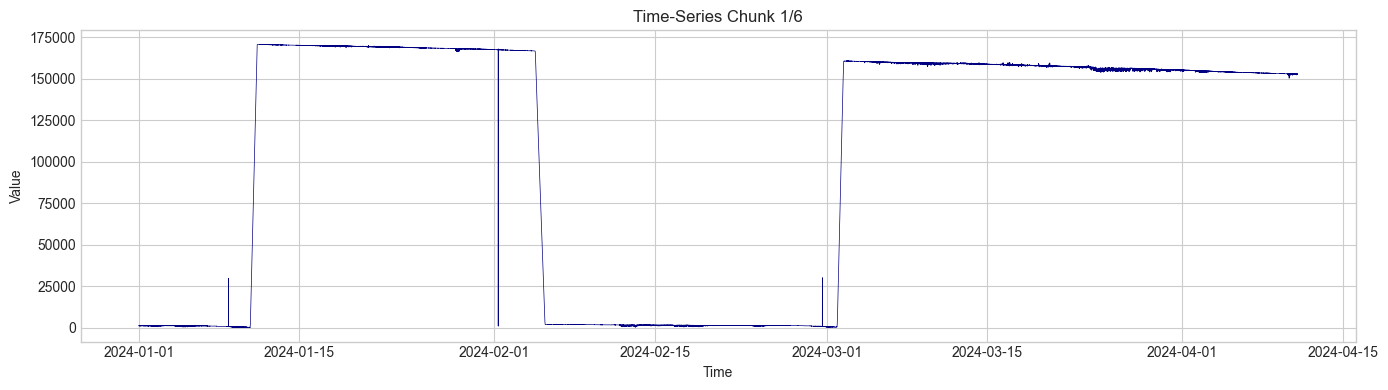

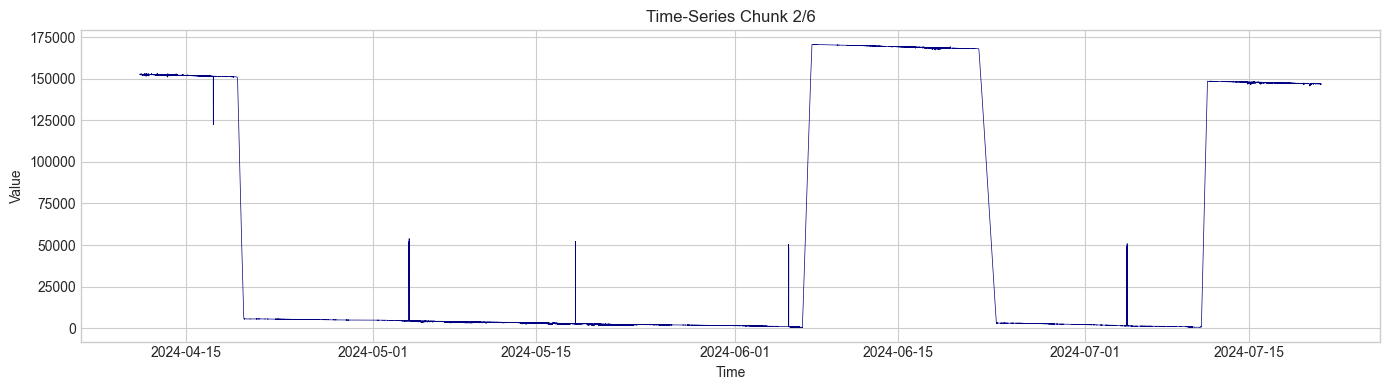

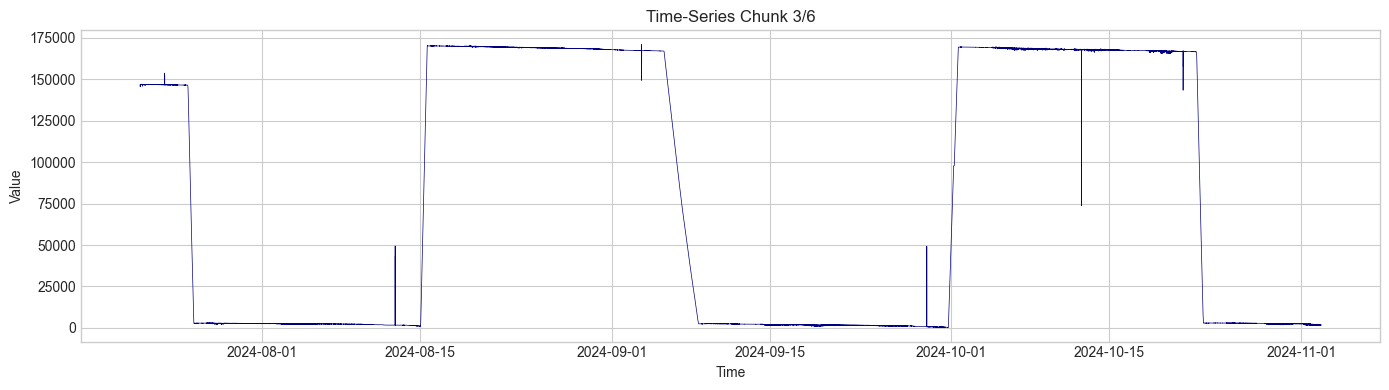

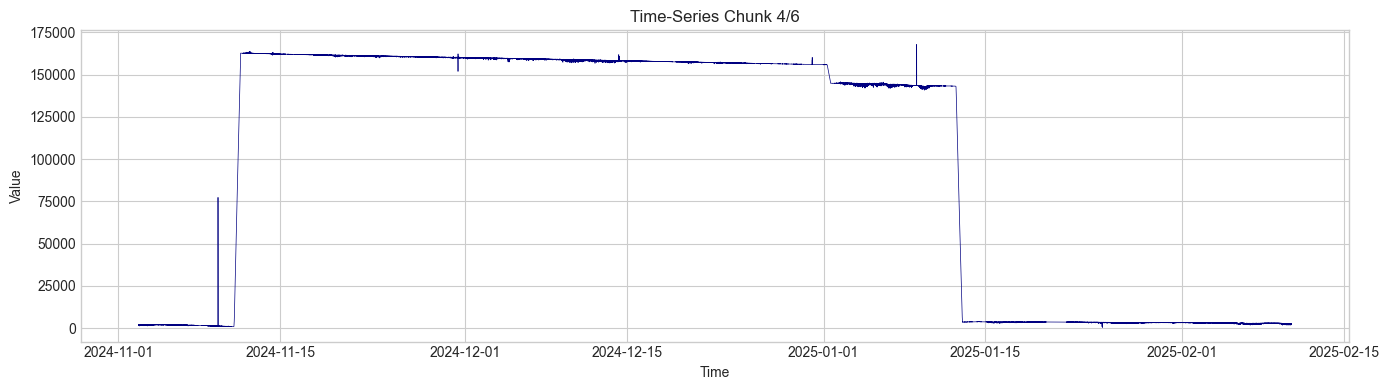

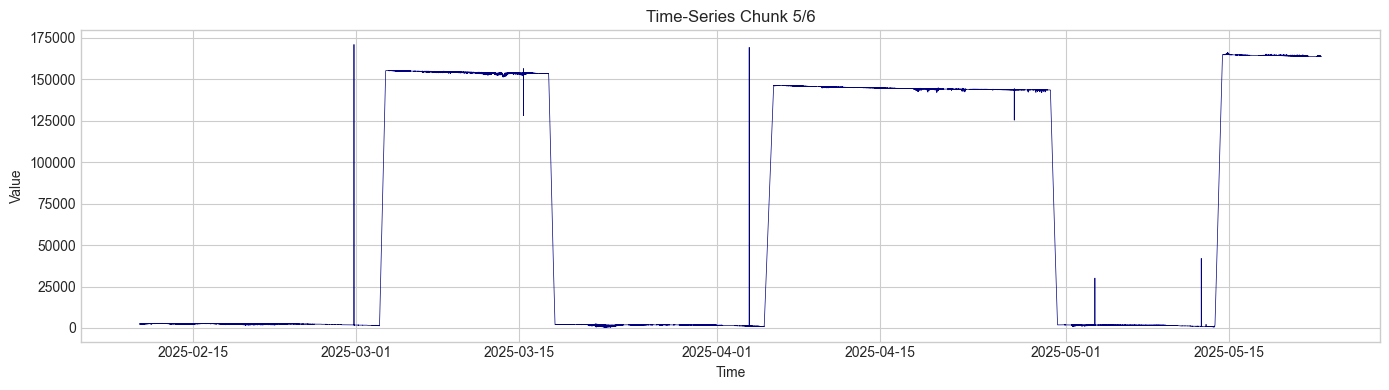

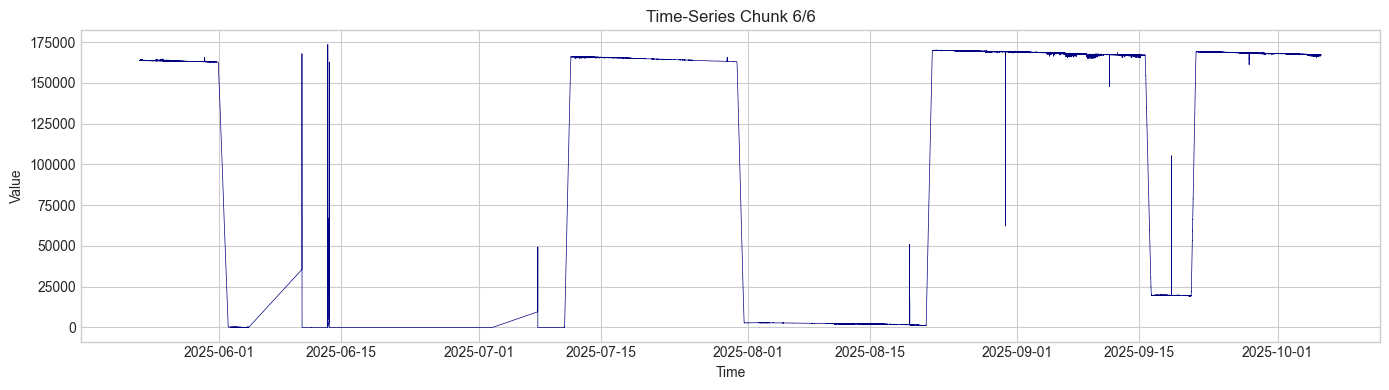


=== GLOBAL STATISTICS ===


count    3.807902e+06
mean     8.835446e+04
std      7.803013e+04
min      0.000000e+00
1%       6.239950e+02
5%       1.214392e+03
25%      2.294074e+03
50%      1.442680e+05
75%      1.634918e+05
95%      1.693659e+05
99%      1.701197e+05
max      1.736328e+05
Name: Value, dtype: float64

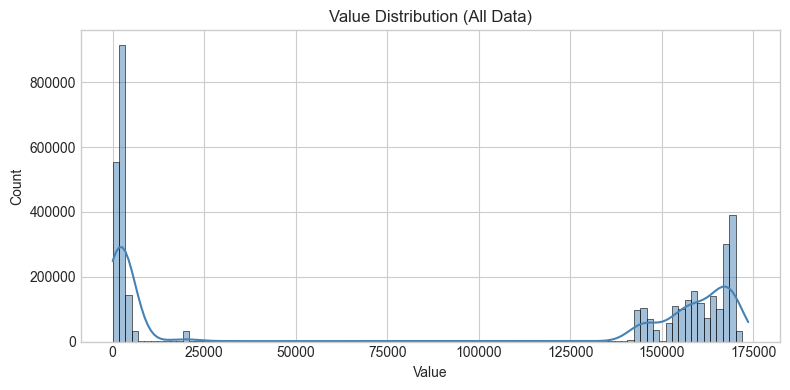

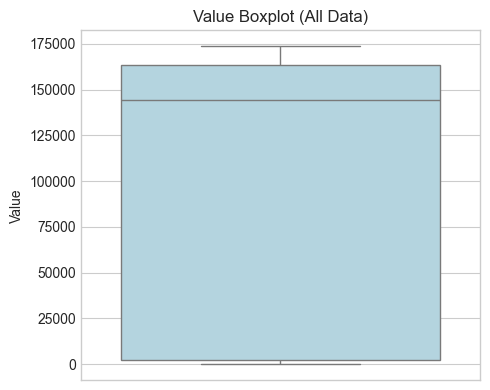

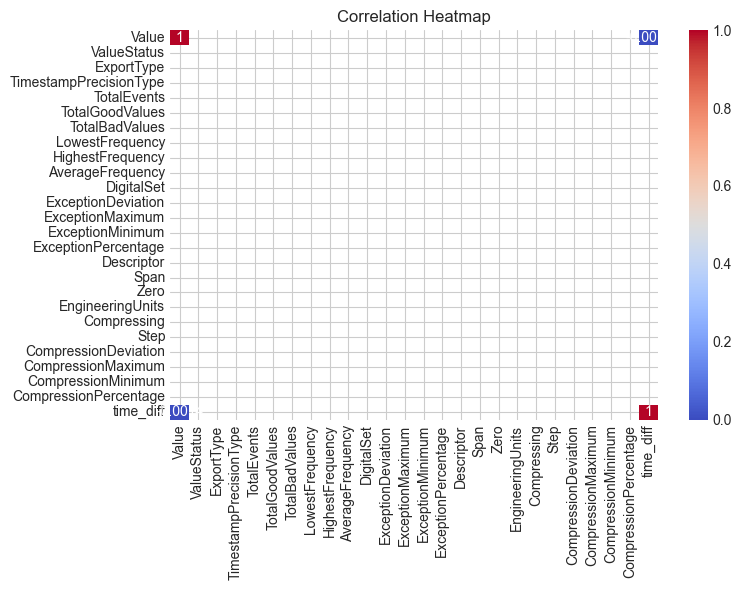


=== CHUNKED VISUALIZATION COMPLETE ===


In [ ]:
eda_large(df1)

In [ ]:
def eda_datashader_full(df, value_col='Value', time_col='Timestamp', category_cols=None, output_name='eda_full'):
    """
    Full visual exploratory data analysis without modifying or cleaning the data.
    Includes:
    - Full Datashader visualization
    - Segment-wise zooms
    - Distribution plots
    - Whisker (box) & quantile plots
    - Outlier detection (Z-score and IQR)
    - Category-based distributions
    """

    print("=== FULL EDA START ===")
    print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")

    # --- Basic Info ---
    print("\n=== BASIC INFO ===")
    print(df.info())
    print("\n=== SUMMARY STATISTICS ===")
    display(df.describe(include='all').T)

    # === DATASHADER VISUALIZATIONS ===
    print("\nGenerating Datashader full-series plot...")
    try:
        df["time_numeric"] = pd.to_datetime(df[time_col], errors='coerce').astype('int64') / 1e9
        cvs = ds.Canvas(plot_width=2500, plot_height=500)
        agg = cvs.line(df, x="time_numeric", y=value_col)
        img = tf.shade(agg, cmap=["#c6dbef", "#08306b"], how="linear")
        final_img = tf.set_background(img, "white").to_pil()
        final_img.save(f"{output_name}_datashader_full.png")
        print(f"Saved: {output_name}_datashader_full.png")

        # Zoomed segments (5 equal parts)
        n_segments = 5
        seg_len = len(df) // n_segments
        for i in range(n_segments):
            seg = df.iloc[i*seg_len:(i+1)*seg_len]
            cvs_seg = ds.Canvas(plot_width=1500, plot_height=300)
            agg_seg = cvs_seg.line(seg, x="time_numeric", y=value_col)
            img_seg = tf.shade(agg_seg, cmap=["#9ecae1", "#08519c"], how="linear")
            tf.set_background(img_seg, "white").to_pil().save(f"{output_name}_segment{i+1}.png")
        print(f"Saved {n_segments} zoomed segment plots.")

    except Exception as e:
        print("Datashader visualization failed:", e)

    # === DISTRIBUTION PLOTS ===
    print("\nGenerating distributions and boxplots...")
    plt.figure(figsize=(10, 4))
    sns.histplot(df[value_col], bins=80, kde=True, color='steelblue')
    plt.title("Value Distribution")
    plt.tight_layout()
    plt.savefig(f"{output_name}_hist.png", dpi=150)
    plt.show()

    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df[value_col], color='#a6cee3')
    plt.title("Boxplot (Whisker Plot)")
    plt.tight_layout()
    plt.savefig(f"{output_name}_boxplot.png", dpi=150)
    plt.show()

    # === QUANTILE PLOT ===
    print("\nQuantile Distribution Plot...")
    quantiles = np.linspace(0, 1, 100)
    values = np.quantile(df[value_col].dropna(), quantiles)
    plt.figure(figsize=(8, 4))
    plt.plot(quantiles, values, color='navy')
    plt.xlabel('Quantile')
    plt.ylabel(value_col)
    plt.title("Quantile Plot")
    plt.tight_layout()
    plt.savefig(f"{output_name}_quantile.png", dpi=150)
    plt.show()

    # === OUTLIER DETECTION ===
    print("\nOutlier detection (Z-score & IQR)...")
    series = df[value_col].dropna()
    z_scores = np.abs(stats.zscore(series))
    iqr = np.percentile(series, 75) - np.percentile(series, 25)
    lower, upper = np.percentile(series, 25) - 1.5 * iqr, np.percentile(series, 75) + 1.5 * iqr
    z_outliers = np.sum(z_scores > 3)
    iqr_outliers = np.sum((series < lower) | (series > upper))
    print(f"Z-score Outliers: {z_outliers:,}")
    print(f"IQR Outliers: {iqr_outliers:,}")

    plt.figure(figsize=(8, 4))
    sns.histplot(series, bins=80, color='lightgray', label='Normal Range')
    plt.axvline(upper, color='red', ls='--', label='Upper IQR Bound')
    plt.axvline(lower, color='red', ls='--', label='Lower IQR Bound')
    plt.legend()
    plt.title("Outlier Boundaries (IQR Method)")
    plt.tight_layout()
    plt.savefig(f"{output_name}_outliers.png", dpi=150)
    plt.show()

    # === CATEGORY DISTRIBUTIONS ===
    if category_cols:
        print("\nCategory-based Distributions...")
        for col in category_cols:
            if col in df.columns:
                plt.figure(figsize=(8, 4))
                sns.boxplot(x=col, y=value_col, data=df, palette='Blues')
                plt.title(f"{value_col} by {col}")
                plt.tight_layout()
                plt.savefig(f"{output_name}_{col}_boxplot.png", dpi=150)
                plt.show()

                plt.figure(figsize=(8, 4))
                sns.violinplot(x=col, y=value_col, data=df, inner="quart", palette='Blues')
                plt.title(f"Distribution by {col} (Violin Plot)")
                plt.tight_layout()
                plt.savefig(f"{output_name}_{col}_violin.png", dpi=150)
                plt.show()

    print("\n=== EDA COMPLETE ===")


=== FULL EDA START ===
Rows: 3,808,515 | Columns: 40

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3808515 entries, 0 to 3808514
Data columns (total 40 columns):
 #   Column                  Dtype              
---  ------                  -----              
 0   Timestamp               datetime64[ns, UTC]
 1   Value                   float64            
 2   ValueStatus             float64            
 3   ExportDate              object             
 4   ExportVersion           object             
 5   ExportType              int64              
 6   TimestampPrecisionType  int64              
 7   ExportFrom              object             
 8   ExportTo                object             
 9   IncludeBadValues        bool               
 10  TotalEvents             int64              
 11  TotalGoodValues         int64              
 12  TotalBadValues          int64              
 13  LowestFrequency         float64            
 14  HighestFrequency        f

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Timestamp,3808201,NaN,NaN,NaN,2024-11-05 22:39:51.745488128+00:00,2024-01-01 00:00:01.711013700+00:00,2024-05-31 11:06:30.812011776+00:00,2024-11-02 17:40:31.511001600+00:00,2025-04-01 01:20:16.410003712+00:00,2025-10-05 23:59:45.910003600+00:00,NaN
Value,3807902.0,NaN,NaN,NaN,88354.458721,0.0,2294.074,144268.0,163491.8,173632.8,78030.12833
ValueStatus,3808201.0,NaN,NaN,NaN,0.999921,0.0,1.0,1.0,1.0,1.0,0.008861
ExportDate,3808515,1,2025-10-06T08:09:02.411285+01:00,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportVersion,3808515,1,1.1.3,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportType,3808515.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,0.0
TimestampPrecisionType,3808515.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
ExportFrom,3808515,1,2024-01-01T00:00:00Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportTo,3808515,1,2025-10-05T23:59:59.9999999Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncludeBadValues,3808515,1,True,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Generating Datashader full-series plot...
Saved: eda_full_datashader_full.png
Saved 5 zoomed segment plots.

Generating distributions and boxplots...


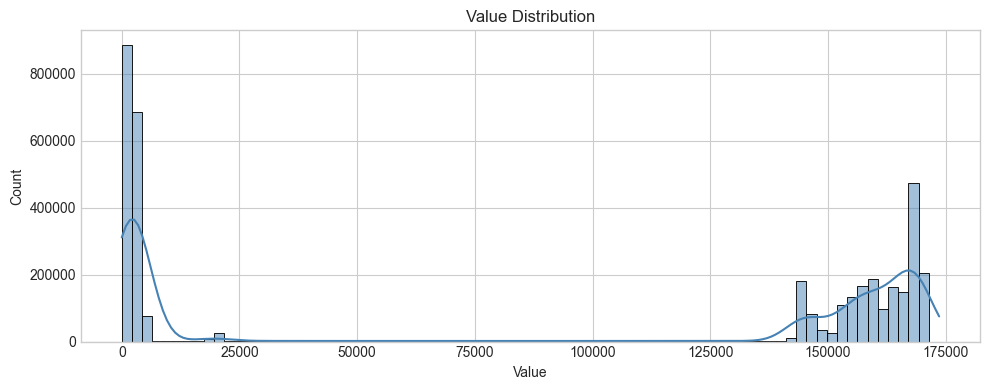

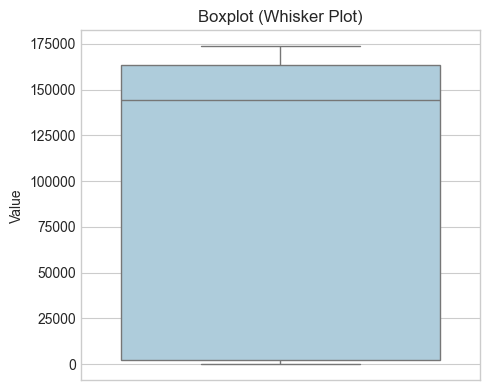


Quantile Distribution Plot...


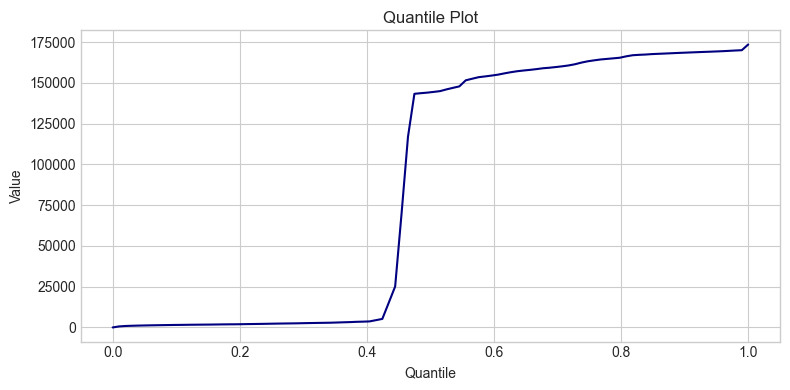


Outlier detection (Z-score & IQR)...
Z-score Outliers: 0
IQR Outliers: 0


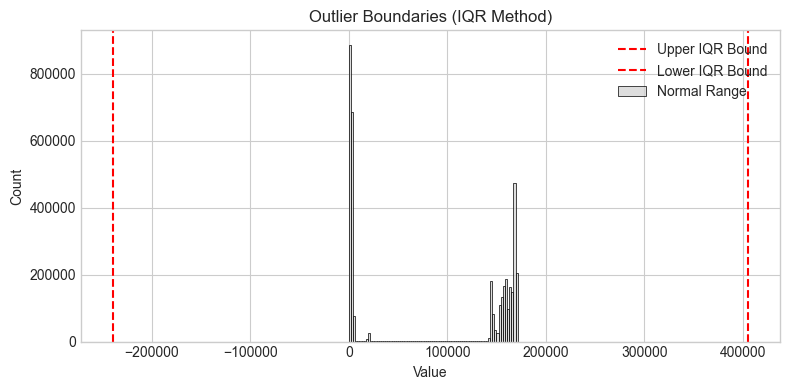


=== EDA COMPLETE ===


In [ ]:
eda_datashader_full(df1)

Numeric columns: ['Value', 'ValueStatus', 'ExportType', 'TimestampPrecisionType', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues', 'LowestFrequency', 'HighestFrequency', 'AverageFrequency', 'DigitalSet', 'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum', 'ExceptionPercentage', 'Descriptor', 'Span', 'Zero', 'EngineeringUnits', 'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum', 'CompressionMinimum', 'CompressionPercentage', 'time_diff', 'time_numeric']
Categorical columns: ['Timestamp', 'ExportDate', 'ExportVersion', 'ExportFrom', 'ExportTo', 'IncludeBadValues', 'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer', 'PiPointName', 'PointSource', 'PointType', 'SanitizedFilename', 'sensor_id']


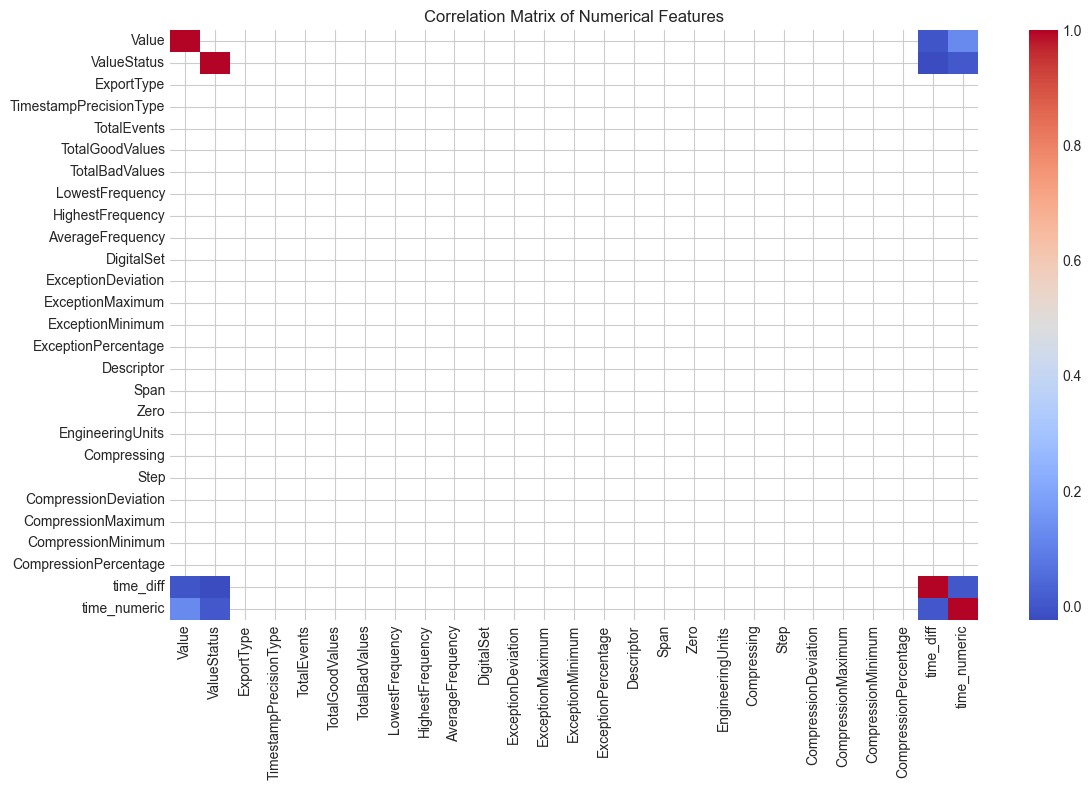

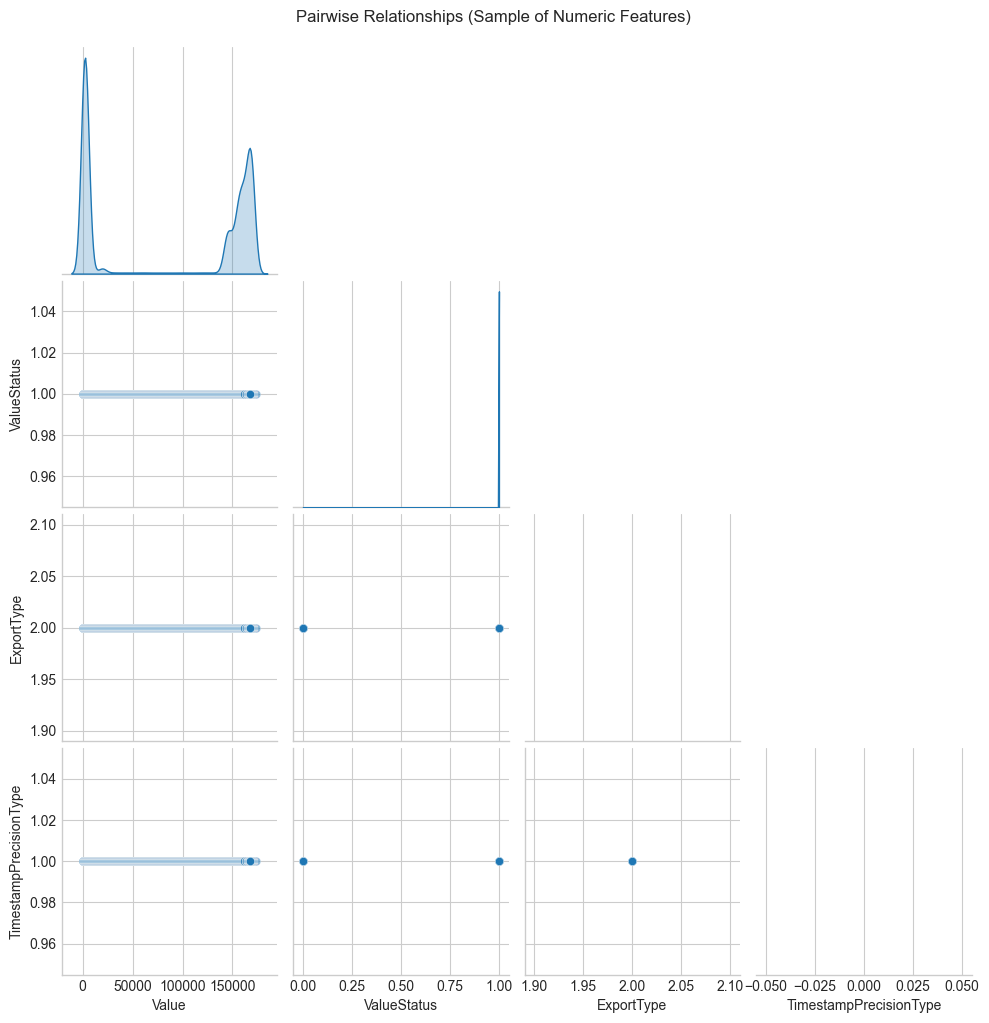

: 

In [ ]:
# ===============================================
# ADVANCED EDA (PART 2) — NO CLEANING
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datashader as ds
import datashader.transfer_functions as tf
import colorcet
import hvplot.pandas  # enables df.hvplot()
import holoviews as hv
from datashader.mpl_ext import dsshow
from holoviews.operation.datashader import datashade, dynspread
hv.extension('bokeh')

# ---- Load Data ----
df = df1.copy()

# Detect numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# =====================================================
# 1. Correlation Matrix
# =====================================================
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# =====================================================
# 2. Pairwise Relationships (Reduced Subset)
# =====================================================
subset_cols = num_cols[:4]  # visualize first 4 numerical columns to avoid clutter
sns.pairplot(df[subset_cols], corner=True, diag_kind='kde', plot_kws={'alpha':0.3})
plt.suptitle("Pairwise Relationships (Sample of Numeric Features)", y=1.02)
plt.show()

# =====================================================
# 3. Category Impact on Numerical Features
# =====================================================
for cat in cat_cols[:3]:  # limit to 3 top categorical columns
    plt.figure(figsize=(10,6))
    sns.boxplot(x=cat, y=num_cols[0], data=df, showfliers=True, palette="cool")
    plt.title(f"Distribution of {num_cols[0]} by {cat}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =====================================================
# 4. Datashader Density Map (for very large datasets)
# =====================================================
x_col, y_col = num_cols[0], num_cols[1] if len(num_cols) > 1 else (num_cols[0], num_cols[0])

canvas = ds.Canvas(plot_width=1000, plot_height=600)
agg = canvas.points(df, x_col, y_col, agg=ds.count())
img = tf.shade(agg, cmap=colorcet.fire, how='eq_hist')

tf.set_background(img, "black").to_pil().save("datashader_density.png")
img

# =====================================================
# 5. Interactive Density Exploration (hvPlot)
# =====================================================
df.hvplot.scatter(
    x=x_col, y=y_col, c='blue', alpha=0.3,
    width=800, height=600,
    title=f"Interactive Scatter with hvPlot ({x_col} vs {y_col})"
)

# =====================================================
# 6. Outlier Detection per Category (Box + Strip Overlay)
# =====================================================
for cat in cat_cols[:2]:
    plt.figure(figsize=(12,6))
    sns.boxplot(x=cat, y=num_cols[0], data=df, showfliers=False, color='skyblue')
    sns.stripplot(x=cat, y=num_cols[0], data=df, alpha=0.1, color='black')
    plt.title(f"Outliers and Distribution of {num_cols[0]} by {cat}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =====================================================
# 7. Quantile vs Category Comparison
# =====================================================
for col in num_cols[:2]:
    quantiles = df[col].quantile([0.25, 0.5, 0.75, 0.9, 0.99])
    print(f"\nQuantiles for {col}:\n{quantiles}")

    plt.figure(figsize=(8,5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot + Quantiles for {col}")
    plt.ylabel(col)
    plt.show()

# =====================================================
# 8. Parallel Coordinates Plot (if moderate feature count)
# =====================================================
from pandas.plotting import parallel_coordinates

if len(num_cols) <= 8 and cat_cols:
    plt.figure(figsize=(12,6))
    parallel_coordinates(df[[*num_cols[:6], cat_cols[0]]], class_column=cat_cols[0], color=sns.color_palette("husl"))
    plt.title(f"Parallel Coordinates for Top Features grouped by {cat_cols[0]}")
    plt.tight_layout()
    plt.show()


In [ ]:
# ===============================================
# PARALLELIZED OUTLIER PROFILING (HPC-READY)
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from joblib import Parallel, delayed
import datashader as ds
import datashader.transfer_functions as tf
import colorcet
import dask.dataframe as dd  # Optional for large-scale parallelization

# Load your dataset
df = df1.copy()

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].copy()

# =====================================================
# 1. Z-SCORE BASED OUTLIER DETECTION (VECTORIZED)
# =====================================================
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))
threshold = 3
outlier_mask_z = (z_scores > threshold).any(axis=1)
df['is_outlier_zscore'] = outlier_mask_z

# =====================================================
# 2. IQR VISUALIZATION (PARALLELIZED)
# =====================================================
def plot_iqr_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], color="lightblue")
    plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
    plt.title(f"IQR Outlier Detection: {col}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"IQR_{col}.png")
    plt.close()

# Run the IQR plotting in parallel for up to 8 columns at a time
Parallel(n_jobs=-1, backend="loky")(delayed(plot_iqr_outliers)(col) for col in num_cols[:8])

# =====================================================
# 3. ISOLATION FOREST (MULTI-CORE)
# =====================================================
iso_forest = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
df['iso_outlier'] = iso_forest.fit_predict(df_num.fillna(0))
df['iso_outlier'] = df['iso_outlier'].apply(lambda x: 1 if x == -1 else 0)

# =====================================================
# 4. LOCAL OUTLIER FACTOR (MULTI-CORE)
# =====================================================
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01, n_jobs=-1)
y_pred_lof = lof.fit_predict(df_num.fillna(0))
df['lof_outlier'] = np.where(y_pred_lof == -1, 1, 0)

# =====================================================
# 5. COMPARISON OF METHODS
# =====================================================
methods = ['is_outlier_zscore', 'iso_outlier', 'lof_outlier']
plt.figure(figsize=(8,5))
sns.heatmap(df[methods].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Outlier Detection Methods")
plt.show()

# =====================================================
# 6. DENSITY VISUALIZATION (OPTIONAL: DASK + DATASHADER)
# =====================================================
ddf = dd.from_pandas(df, npartitions=4)  # For large datasets
x_col, y_col = num_cols[0], num_cols[1] if len(num_cols) > 1 else num_cols[0]

canvas = ds.Canvas(plot_width=1000, plot_height=600)
agg_all = canvas.points(ddf.compute(), x_col, y_col, agg=ds.count())
agg_outliers = canvas.points(ddf[ddf['iso_outlier'] == 1].compute(), x_col, y_col, agg=ds.count())

img_all = tf.shade(agg_all, cmap=colorcet.coolwarm, how='eq_hist')
img_out = tf.shade(agg_outliers, cmap=['red'], how='eq_hist')
combined = tf.stack(img_all, img_out, how='add')
tf.set_background(combined, "black").to_pil().save("datashader_outliers.png")

# =====================================================
# 7. MULTI-METHOD OUTLIER SUMMARY
# =====================================================
summary = pd.DataFrame({
    "Z-Score Outliers": df['is_outlier_zscore'].sum(),
    "Isolation Forest Outliers": df['iso_outlier'].sum(),
    "LOF Outliers": df['lof_outlier'].sum()
}, index=["Total Count"]).T

print("\nOutlier Detection Summary:")
print(summary)

summary.plot(kind='bar', color=['#6fa8dc', '#e06666', '#8e7cc3'], figsize=(8,5), legend=False)
plt.title("Outlier Count Comparison Across Methods")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Data split into 6 chunks. Each chunk has ~634753 rows.

🔹 Running EDA for Chunk 1/6 — Rows: 634753
Numeric columns: ['ValueStatus', 'ExportType', 'TimestampPrecisionType', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues', 'LowestFrequency', 'HighestFrequency', 'AverageFrequency', 'DigitalSet', 'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum', 'ExceptionPercentage', 'Descriptor', 'Span', 'Zero', 'EngineeringUnits', 'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum', 'CompressionMinimum', 'CompressionPercentage']
Categorical columns: ['Timestamp', 'Value', 'ExportDate', 'ExportVersion', 'ExportFrom', 'ExportTo', 'IncludeBadValues', 'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer', 'PiPointName', 'PointSource', 'PointType', 'SanitizedFilename', 'sensor_id']


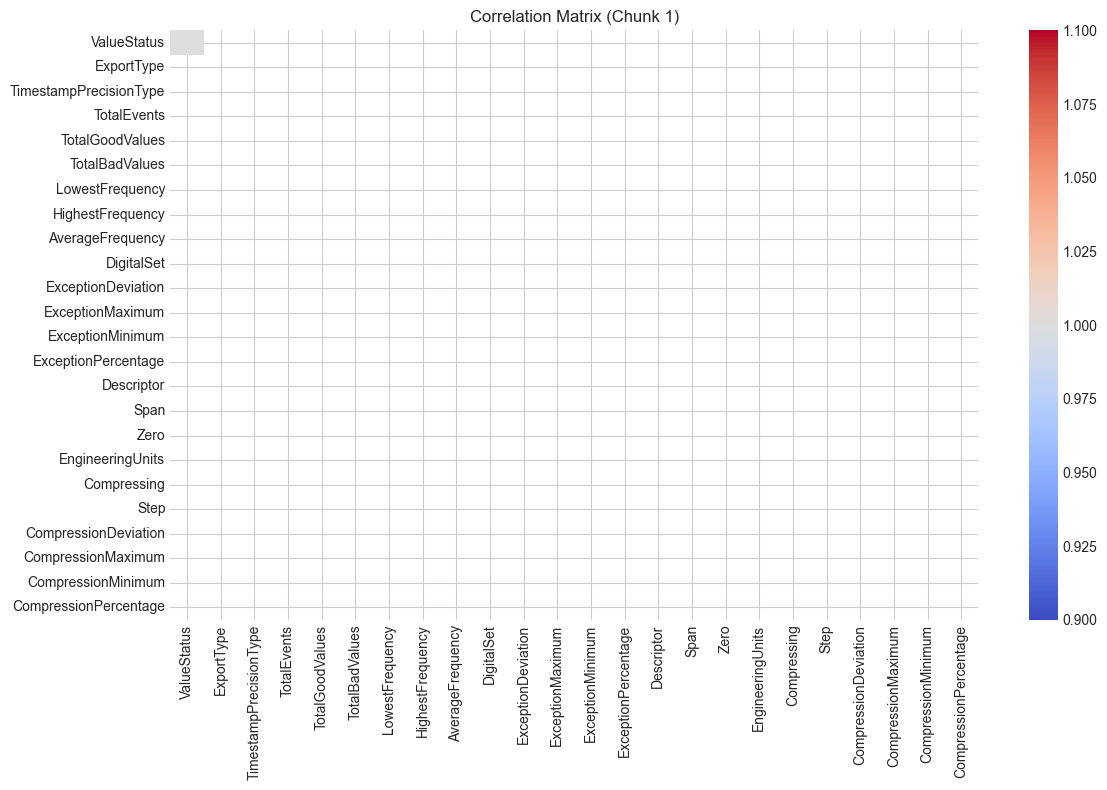

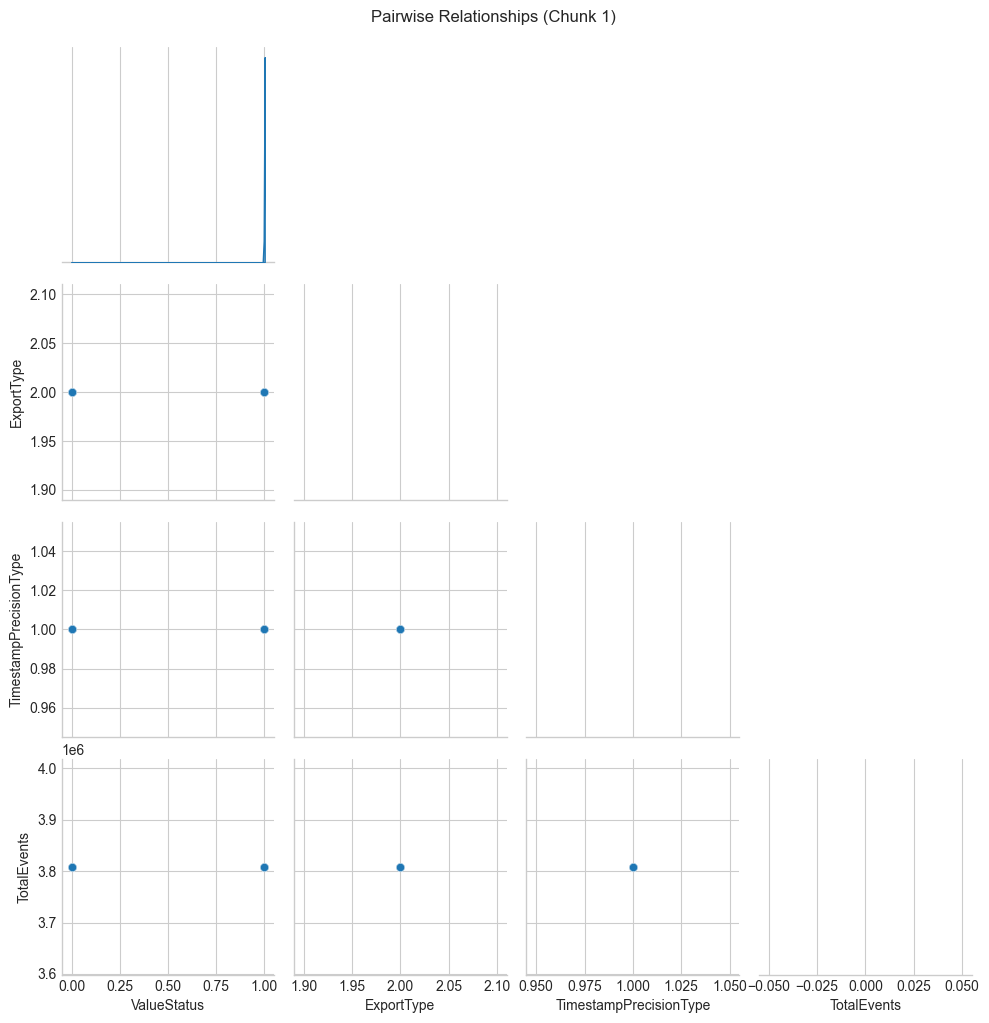

🖼️  Datashader density map saved for chunk 1.



In [ ]:
# ===============================================
# ADVANCED EDA (PART 2) — NO CLEANING, CHUNKED
# ===============================================

# ---- Load Data ----
df = df1.copy()

# ---- Split Data into 6 Chunks ----
chunks = np.array_split(df, 6)
print(f"Data split into {len(chunks)} chunks. Each chunk has ~{len(chunks[0])} rows.\n")

# =====================================================
# LOOP THROUGH EACH CHUNK AND RUN EDA
# =====================================================
for i, chunk in enumerate(chunks):
    print(f"🔹 Running EDA for Chunk {i+1}/{len(chunks)} — Rows: {len(chunk)}")

    # Detect numeric and categorical columns
    num_cols = chunk.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = chunk.select_dtypes(exclude=[np.number]).columns.tolist()

    print(f"Numeric columns: {num_cols}")
    print(f"Categorical columns: {cat_cols}")

    # =====================================================
    # 1. Correlation Matrix
    # =====================================================
    if len(num_cols) > 1:
        plt.figure(figsize=(12,8))
        corr = chunk[num_cols].corr()
        sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
        plt.title(f"Correlation Matrix (Chunk {i+1})")
        plt.tight_layout()
        plt.show()

    # =====================================================
    # 2. Pairwise Relationships (Reduced Subset)
    # =====================================================
    if len(num_cols) >= 4:
        subset_cols = num_cols[:4]
        sns.pairplot(chunk[subset_cols], corner=True, diag_kind='kde', plot_kws={'alpha':0.3})
        plt.suptitle(f"Pairwise Relationships (Chunk {i+1})", y=1.02)
        plt.show()
    """

    # =====================================================
    # 3. Category Impact on Numerical Features
    # =====================================================
    for cat in cat_cols[:3]:
        plt.figure(figsize=(10,6))
        sns.boxplot(x=cat, y=num_cols[0], data=chunk, showfliers=True, palette="cool")
        plt.title(f"Distribution of {num_cols[0]} by {cat} (Chunk {i+1})")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    """
    # =====================================================
    # 4. Datashader Density Map
    # =====================================================
    if len(num_cols) >= 2:
        x_col, y_col = num_cols[0], num_cols[1]
        canvas = ds.Canvas(plot_width=1000, plot_height=600)
        agg = canvas.points(chunk, x_col, y_col, agg=ds.count())
        img = tf.shade(agg, cmap=colorcet.fire, how='eq_hist')
        tf.set_background(img, "black").to_pil().save(f"datashader_density_chunk{i+1}.png")
        print(f"🖼️  Datashader density map saved for chunk {i+1}.\n")

    # =====================================================
    # 5. Interactive Density Exploration (hvPlot)
    # =====================================================
    if len(num_cols) >= 2:
        chunk.hvplot.scatter(
            x=num_cols[0], y=num_cols[1], c='blue', alpha=0.3,
            width=800, height=600,
            title=f"Interactive Scatter (Chunk {i+1})"
        )

    # =====================================================
    # 6. Outlier Detection per Category (Box + Strip Overlay)
    # =====================================================
    for cat in cat_cols[:2]:
        plt.figure(figsize=(12,6))
        sns.boxplot(x=cat, y=num_cols[0], data=chunk, showfliers=False, color='skyblue')
        sns.stripplot(x=cat, y=num_cols[0], data=chunk, alpha=0.1, color='black')
        plt.title(f"Outliers and Distribution of {num_cols[0]} by {cat} (Chunk {i+1})")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # =====================================================
    # 7. Quantile vs Category Comparison
    # =====================================================
    for col in num_cols[:2]:
        quantiles = chunk[col].quantile([0.25, 0.5, 0.75, 0.9, 0.99])
        print(f"\nQuantiles for {col} (Chunk {i+1}):\n{quantiles}")

        plt.figure(figsize=(8,5))
        sns.boxplot(y=chunk[col])
        plt.title(f"Boxplot + Quantiles for {col} (Chunk {i+1})")
        plt.ylabel(col)
        plt.show()

    # =====================================================
    # 8. Parallel Coordinates Plot (if moderate feature count)
    # =====================================================
    if len(num_cols) <= 8 and cat_cols:
        plt.figure(figsize=(12,6))
        pd.parallel_coordinates(chunk[[*num_cols[:6], cat_cols[0]]], class_column=cat_cols[0], color=sns.color_palette("husl"))
        plt.title(f"Parallel Coordinates (Chunk {i+1})")
        plt.tight_layout()
        plt.show()

    print(f"Finished EDA for Chunk {i+1}\n{'-'*80}\n")

print("🎉 EDA complete for all 6 chunks!")


/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_14121/3238645681.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_14121/3238645681.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_outlier_zscore', data=df, palette='cool')


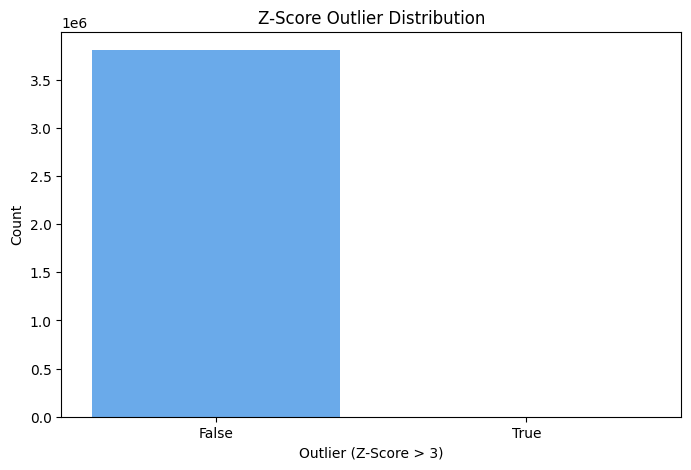

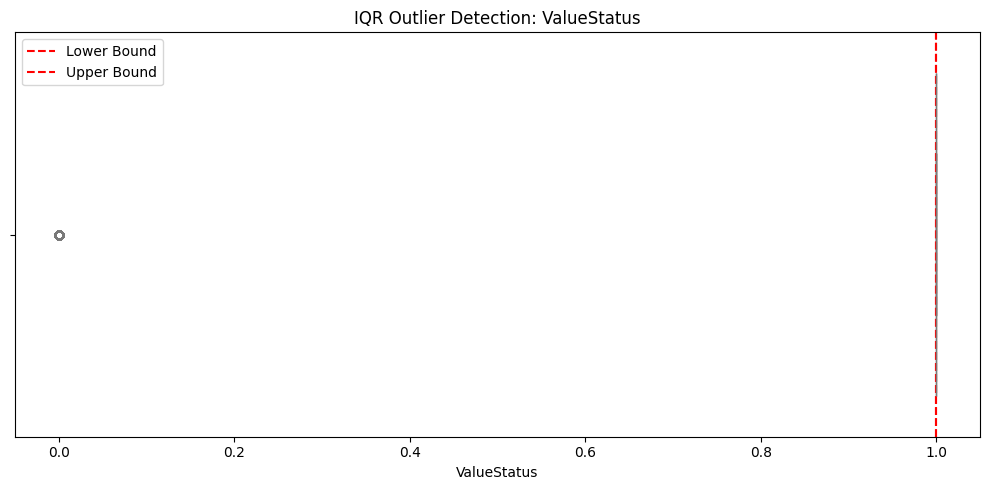

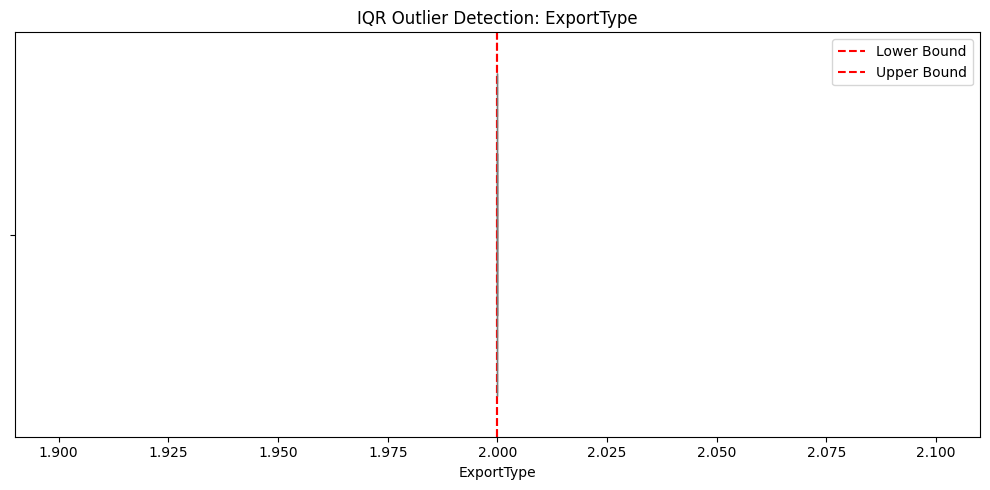

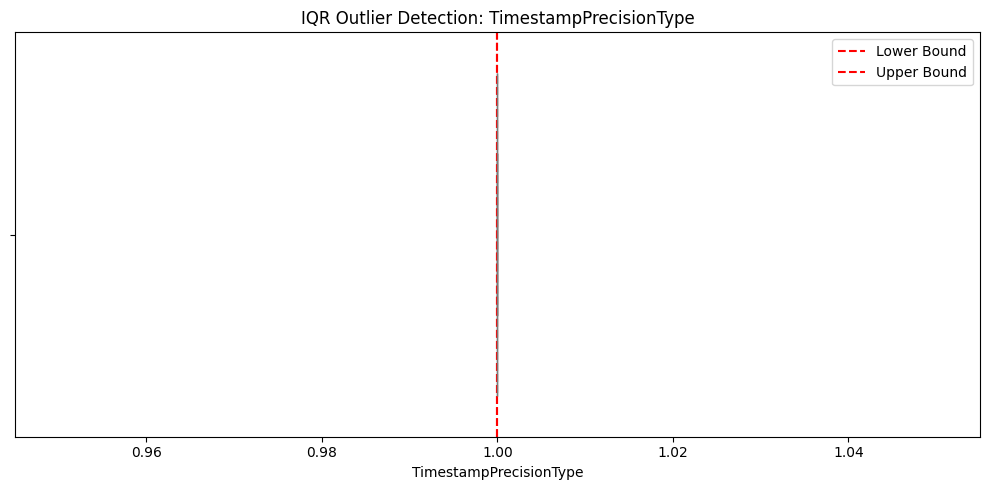

/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_14121/3238645681.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='iso_outlier', data=df, palette='coolwarm')


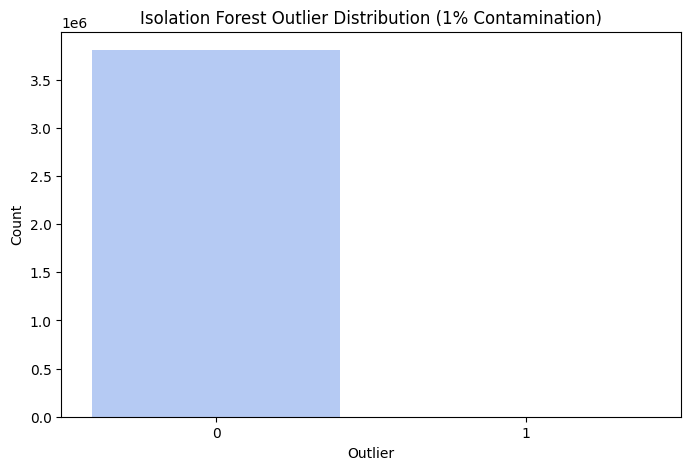

In [ ]:
# ===============================================
# ADVANCED OUTLIER PROFILING (PART 2.5)
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import datashader as ds
import datashader.transfer_functions as tf
import colorcet

df = df1.copy()
# Select numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].copy()

# =====================================================
# 1. Z-Score Based Outlier Detection
# =====================================================
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))
threshold = 3
outlier_mask_z = (z_scores > threshold).any(axis=1)
df['is_outlier_zscore'] = outlier_mask_z

plt.figure(figsize=(8,5))
sns.countplot(x='is_outlier_zscore', data=df, palette='cool')
plt.title("Z-Score Outlier Distribution")
plt.xlabel("Outlier (Z-Score > 3)")
plt.ylabel("Count")
plt.show()

# =====================================================
# 2. IQR (Interquartile Range) Visualization
# =====================================================
for col in num_cols[:3]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], color="lightblue")
    plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
    plt.title(f"IQR Outlier Detection: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================
# 3. Isolation Forest (Density-Based Anomaly Detection)
# =====================================================
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['iso_outlier'] = iso_forest.fit_predict(df_num.fillna(0))
df['iso_outlier'] = df['iso_outlier'].apply(lambda x: 1 if x == -1 else 0)

plt.figure(figsize=(8,5))
sns.countplot(x='iso_outlier', data=df, palette='coolwarm')
plt.title("Isolation Forest Outlier Distribution (1% Contamination)")
plt.xlabel("Outlier")
plt.ylabel("Count")
plt.show()

# =====================================================
# 4. Local Outlier Factor (LOF)
# =====================================================
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
y_pred_lof = lof.fit_predict(df_num.fillna(0))
df['lof_outlier'] = np.where(y_pred_lof == -1, 1, 0)

plt.figure(figsize=(8,5))
sns.countplot(x='lof_outlier', data=df, palette='mako')
plt.title("Local Outlier Factor (LOF) Outlier Distribution")
plt.xlabel("Outlier")
plt.ylabel("Count")
plt.show()

# =====================================================
# 5. Comparison of Outlier Methods
# =====================================================
methods = ['is_outlier_zscore', 'iso_outlier', 'lof_outlier']
plt.figure(figsize=(8,5))
sns.heatmap(df[methods].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Outlier Detection Methods")
plt.show()

# =====================================================
# 6. Density Visualization with Datashader
# =====================================================
x_col, y_col = num_cols[0], num_cols[1] if len(num_cols) > 1 else (num_cols[0], num_cols[0])

canvas = ds.Canvas(plot_width=1000, plot_height=600)
agg_all = canvas.points(df, x_col, y_col, agg=ds.count())
agg_outliers = canvas.points(df[df['iso_outlier'] == 1], x_col, y_col, agg=ds.count())

img_all = tf.shade(agg_all, cmap=colorcet.coolwarm, how='eq_hist')
img_out = tf.shade(agg_outliers, cmap=['red'], how='eq_hist')

combined = tf.stack(img_all, img_out, how='add')
tf.set_background(combined, "black").to_pil().save("datashader_outliers.png")
combined

# =====================================================
# 7. Multi-Method Outlier Summary
# =====================================================
summary = pd.DataFrame({
    "Z-Score Outliers": df['is_outlier_zscore'].sum(),
    "Isolation Forest Outliers": df['iso_outlier'].sum(),
    "LOF Outliers": df['lof_outlier'].sum()
}, index=["Total Count"]).T

print("\nOutlier Detection Summary:")
print(summary)

summary.plot(kind='bar', color=['#6fa8dc', '#e06666', '#8e7cc3'], figsize=(8,5), legend=False)
plt.title("Outlier Count Comparison Across Methods")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# ===============================================
# PART 3 — DIMENSIONALITY REDUCTION & CLUSTER VISUALIZATION
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import datashader as ds
import datashader.transfer_functions as tf
import colorcet
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# Optionally install umap if not present:
# !pip install umap-learn
import umap

# Load Data
df = pd.read_csv("your_large_dataset.csv")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].fillna(0)

# =====================================================
# 1. Feature Scaling
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# =====================================================
# 2. PCA Visualization
# =====================================================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA explained variance (2D): {explained_var:.2f}%")

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, s=3, alpha=0.5)
plt.title(f"PCA Projection (2 Components) — {explained_var:.1f}% Variance Explained")
plt.tight_layout()
plt.show()

# =====================================================
# 3. UMAP Visualization
# =====================================================
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_umap = umap_model.fit_transform(X_scaled)
df_umap = pd.DataFrame(embedding_umap, columns=['UMAP1', 'UMAP2'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='UMAP1', y='UMAP2', data=df_umap, s=3, alpha=0.5, color='steelblue')
plt.title("UMAP Projection (2D)")
plt.tight_layout()
plt.show()

# =====================================================
# 4. t-SNE Visualization (for sample due to complexity)
# =====================================================
sample_size = min(10000, len(df_num))
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
embedding_tsne = tsne.fit_transform(X_scaled[:sample_size])
df_tsne = pd.DataFrame(embedding_tsne, columns=['TSNE1', 'TSNE2'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='TSNE1', y='TSNE2', data=df_tsne, s=4, alpha=0.5, color='darkorange')
plt.title(f"t-SNE Projection (Sample of {sample_size})")
plt.tight_layout()
plt.show()

# =====================================================
# 5. K-Means Clustering (Optional, for Structure Analysis)
# =====================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_umap['cluster'] = kmeans.fit_predict(df_umap)

plt.figure(figsize=(8,6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='cluster', data=df_umap, palette='tab10', s=8)
plt.title(f"K-Means Clustering (k={n_clusters}) on UMAP Projection")
plt.legend(title="Cluster", loc='best')
plt.tight_layout()
plt.show()

# =====================================================
# 6. Datashader Visualization for Full Dataset
# =====================================================
canvas = ds.Canvas(plot_width=1200, plot_height=800)
agg = canvas.points(df_umap, 'UMAP1', 'UMAP2', agg=ds.count())
img = tf.shade(agg, cmap=colorcet.fire, how='eq_hist')
img = tf.set_background(img, "black")
img.to_pil().save("umap_datashader_full.png")
img

# =====================================================
# 7. Cluster Density Visualization (Datashader)
# =====================================================
if 'cluster' in df_umap.columns:
    color_map = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    cluster_agg = canvas.points(df_umap, 'UMAP1', 'UMAP2', agg=ds.by('cluster', ds.count()))
    cluster_img = tf.stack(*[tf.shade(cluster_agg.sel(cluster=i), cmap=[color_map[i]]) for i in range(n_clusters)])
    cluster_img = tf.set_background(cluster_img, "black")
    cluster_img.to_pil().save("umap_clusters_datashader.png")
    cluster_img


## Data Cleaning & Preprocessing
## Correlation Analysis
## Statistical Anomaly Detection
## Machine Learning–Based Anomaly Detection
## Visualization & Results Summary